In [62]:
# Global Energy Consumption Analysis

## Main Objective:
#Analyze energy consumption, sustainability, and carbon emissions using data science techniques.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA


In [38]:
#load data
df= pd.read_csv(r"global_energy_consumption.csv")
df.head()

,Country,Year,Total Energy Consumption (TWh),Per Capita Energy Use (kWh),Renewable Energy Share (%),Fossil Fuel Dependency (%),Industrial Energy Use (%),Household Energy Use (%),Carbon Emissions (Million Tons),Energy Price Index (USD/kWh)
0,Canada,2018,9525.38,42301.43,13.70,70.47,45.18,19.96,3766.11,0.12
1,Germany,2020,7922.08,36601.38,33.63,41.95,34.32,22.27,2713.12,0.08
2,Russia,2002,6630.01,41670.20,10.82,39.32,53.66,26.44,885.98,0.26
3,Brazil,2010,8580.19,10969.58,73.24,16.71,30.55,27.60,1144.11,0.47
4,Canada,2006,848.88,32190.85,73.60,74.86,42.39,23.43,842.39,0.48


In [39]:
#cleaning
print(df.isnull().sum())
df.columns = df.columns.str.strip()
df.describe()
df.dtypes

Country                            0
Year                               0
Total Energy Consumption (TWh)     0
Per Capita Energy Use (kWh)        0
Renewable Energy Share (%)         0
Fossil Fuel Dependency (%)         0
Industrial Energy Use (%)          0
Household Energy Use (%)           0
Carbon Emissions (Million Tons)    0
Energy Price Index (USD/kWh)       0
dtype: int64


Country                             object
Year                                 int64
Total Energy Consumption (TWh)     float64
Per Capita Energy Use (kWh)        float64
Renewable Energy Share (%)         float64
Fossil Fuel Dependency (%)         float64
Industrial Energy Use (%)          float64
Household Energy Use (%)           float64
Carbon Emissions (Million Tons)    float64
Energy Price Index (USD/kWh)       float64
dtype: object


Top Energy Consuming Countries:

Country
USA          5323.466676
Japan        5279.490111
India        5266.872149
UK           5262.176180
Germany      5184.558661
Canada       5086.422684
Russia       5058.404550
Australia    5046.237081
China        5036.665137
Brazil       4858.032318
Name: Total Energy Consumption (TWh), dtype: float64


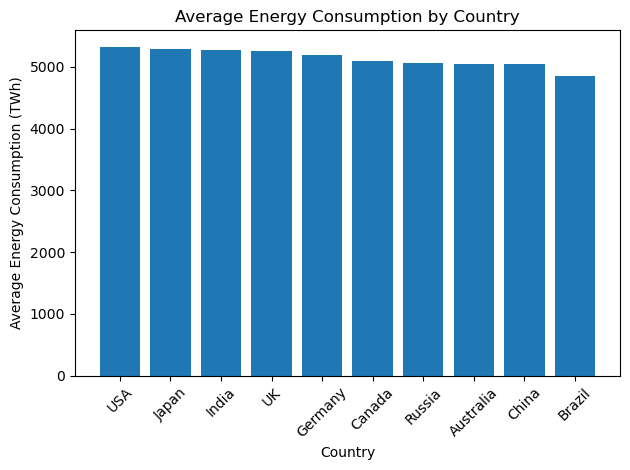

In [40]:
## Objective 1: Global Energy Consumption Trends

#Analyze global energy consumption trends over time by 
#aggregating yearly data to identify long-term growth patterns, fluctuations, and overall demand changes.

#average energy consumption by countries
avg_energy = df.groupby("Country")["Total Energy Consumption (TWh)"].mean()
avg_energy = avg_energy.sort_values(ascending=False)

print("\nTop Energy Consuming Countries:\n")
print(avg_energy)

plt.bar(avg_energy.index, avg_energy.values)

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Average Energy Consumption (TWh)")
plt.title("Average Energy Consumption by Country")

plt.tight_layout()
plt.show()

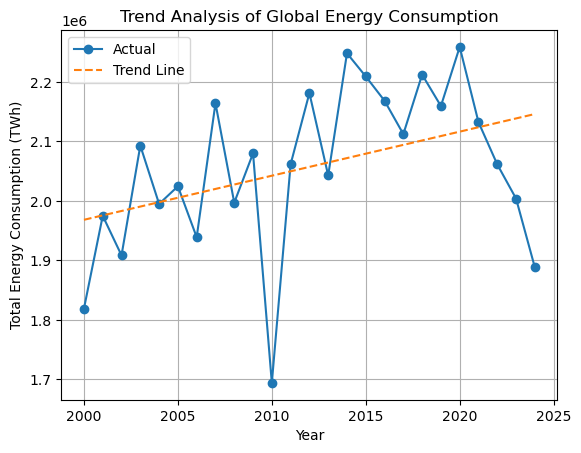

In [55]:
#GLOBAL ENERGY CONSUMPTION TREND OVER TIME

global_trend = df.groupby("Year")["Total Energy Consumption (TWh)"].sum()

z = np.polyfit(global_trend.index, global_trend.values, 1)
p = np.poly1d(z)

plt.plot(global_trend.index, global_trend.values, marker='o', label="Actual")

plt.plot(global_trend.index, p(global_trend.index), '--', label="Trend Line")


plt.xlabel("Year")
plt.ylabel("Total Energy Consumption (TWh)")
plt.title("Trend Analysis of Global Energy Consumption")

plt.legend()
plt.grid(True)
plt.show()

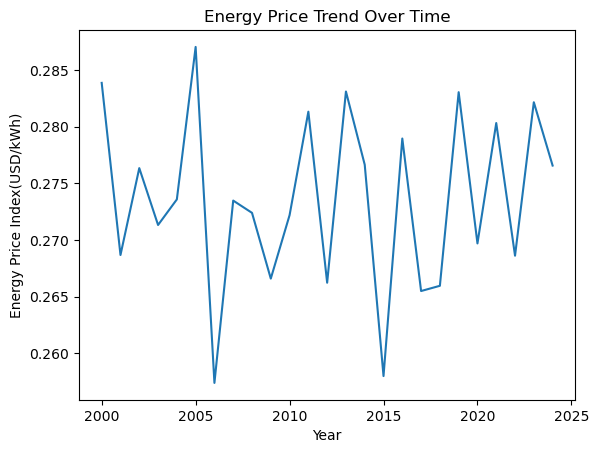

In [41]:
#Energy Price Trend Over Time
price_trend = df.groupby("Year")["Energy Price Index (USD/kWh)"].mean()

plt.plot(price_trend.index, price_trend.values)
plt.xlabel("Year")
plt.ylabel("Energy Price Index(USD/kWh)")
plt.title("Energy Price Trend Over Time")
plt.show()

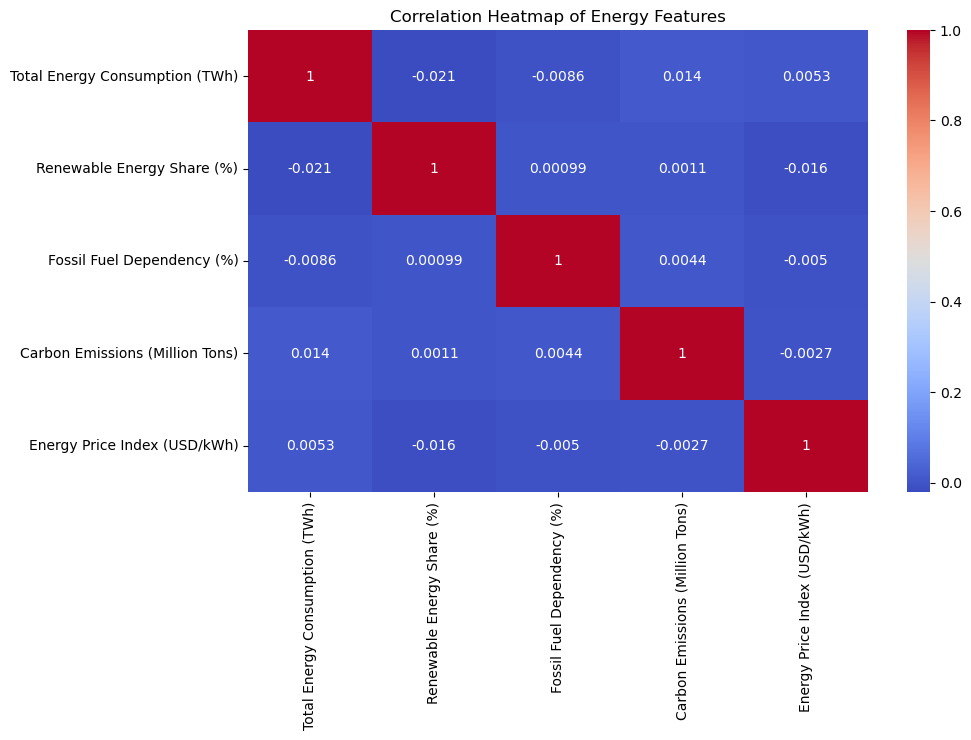

In [54]:
cols = [
    "Total Energy Consumption (TWh)",
    "Renewable Energy Share (%)",
    "Fossil Fuel Dependency (%)",
    "Carbon Emissions (Million Tons)",
    "Energy Price Index (USD/kWh)"
]

corr = df[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Energy Features")
plt.show()

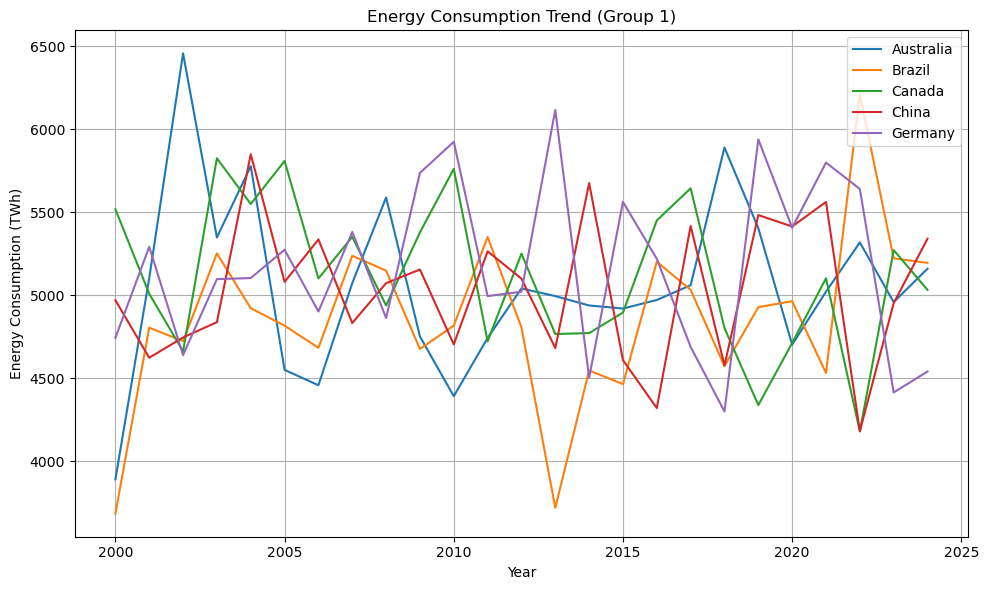

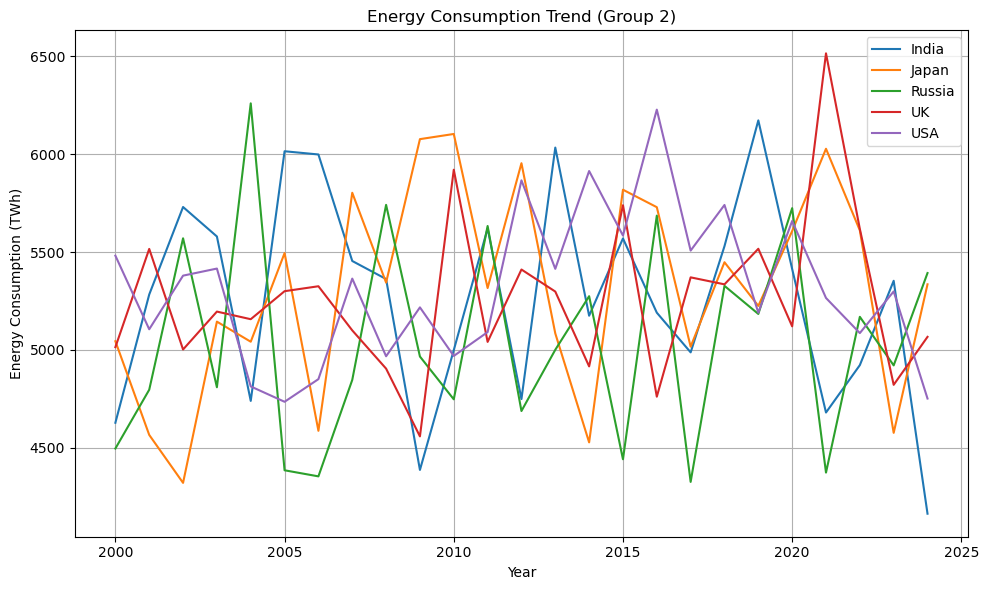

In [43]:
##objective2: Country-wise Energy Analysis

#country wise energy consumption trend

grouped = df.groupby(["Country", "Year"])["Total Energy Consumption (TWh)"].mean().reset_index()

countries = list(grouped["Country"].unique())

mid = len(countries) // 2
group1 = countries[:mid]
group2 = countries[mid:]

def plot_group(group, title):
    plt.figure(figsize=(10,6))

    for country in group:
        subset = grouped[grouped["Country"] == country]
        
        plt.plot(
            subset["Year"],
            subset["Total Energy Consumption (TWh)"],
            label=country
        )

    plt.xlabel("Year")
    plt.ylabel("Energy Consumption (TWh)")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_group(group1, "Energy Consumption Trend (Group 1)")

plot_group(group2, "Energy Consumption Trend (Group 2)")

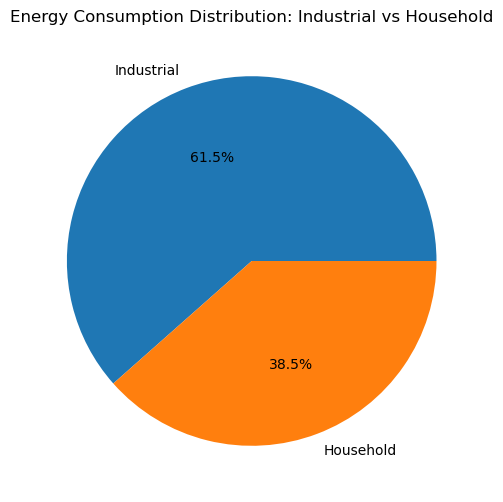

In [44]:
#Energy Consumption Distribution: Industrial vs Household
industrial = df["Industrial Energy Use (%)"].mean()
household = df["Household Energy Use (%)"].mean()

labels = ["Industrial", "Household"]
values = [industrial, household]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Energy Consumption Distribution: Industrial vs Household")
plt.show()

C:\Users\lekts\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


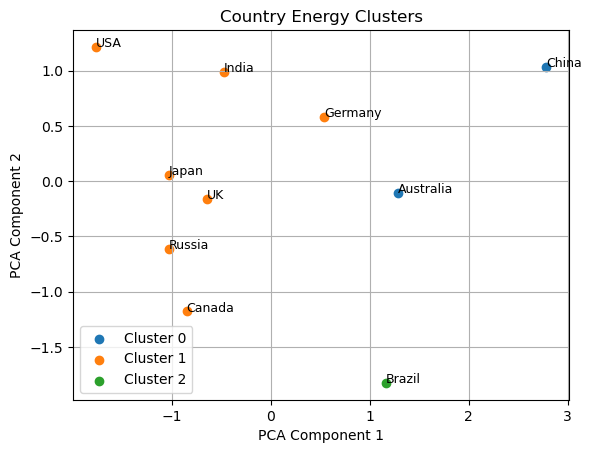


Country Clusters:

Country
Australia    0
Brazil       2
Canada       1
China        0
Germany      1
India        1
Japan        1
Russia       1
UK           1
USA          1
Name: Cluster, dtype: int32


In [28]:
## Objective 3: Country Segmentation

#Cluster countries based on energy behavior.

country_df = df.groupby("Country").mean()

features = [
    "Total Energy Consumption (TWh)",
    "Renewable Energy Share (%)",
    "Fossil Fuel Dependency (%)",
    "Carbon Emissions (Million Tons)"
]

X = country_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#kmean clustering

kmeans = KMeans(n_clusters=3, random_state=42)
country_df["Cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

country_df["PCA1"] = X_pca[:, 0]
country_df["PCA2"] = X_pca[:, 1]

for cluster in range(3):
    subset = country_df[country_df["Cluster"] == cluster]
    
    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=f"Cluster {cluster}"
    )

# label countries
for i in range(len(country_df)):
    plt.text(
        country_df["PCA1"].iloc[i],
        country_df["PCA2"].iloc[i],
        country_df.index[i],
        fontsize=9
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Country Energy Clusters")

plt.legend()
plt.grid(True)
plt.show()

print("\nCountry Clusters:\n")
print(country_df["Cluster"])

In [ ]:
### Insight:
- Cluster 0 → Fossil-heavy countries
- Cluster 1 → Renewable-focused
- Cluster 2 → Transitional economies
Countries are grouped into three distinct clusters based on energy consumption patterns.
These clusters can be interpreted as:
-Cluster 0-Fossil-fuel-dependent countries → high emissions, low renewable share
-Cluster 1-Sustainable countries → higher renewable share, lower emissions
-Cluster 2->Transition economies → moderate values across features
Clustering helps identify hidden patterns and similarities between countries.
PCA visualization makes cluster separation easier to interpret.


Model Performance:

Linear Regression
R2  : 0.0803
RMSE: 1368.91

Random Forest
R2  : 0.9982
RMSE: 60.12


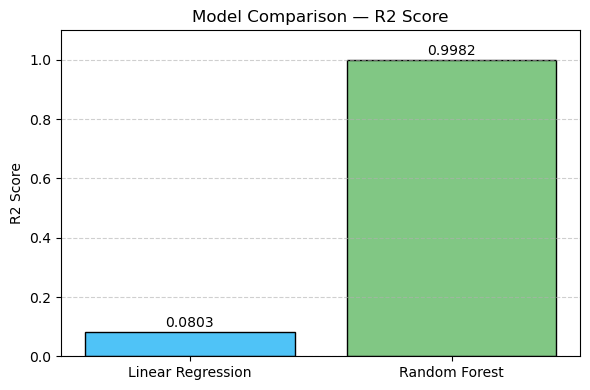

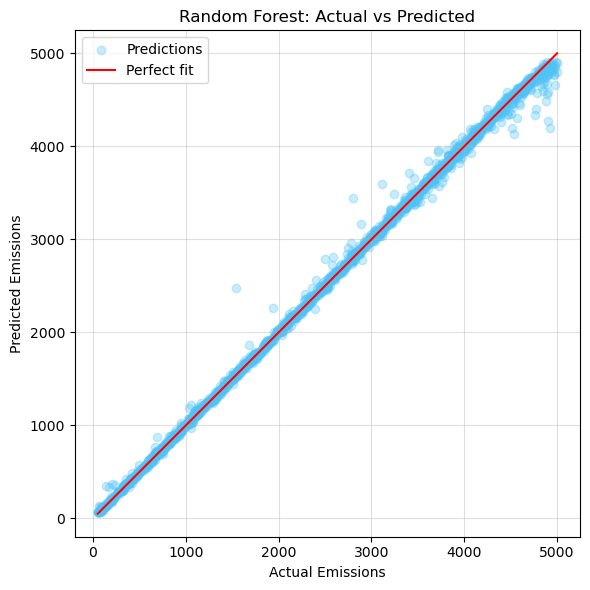

In [29]:
## Objective 4: Carbon Emission Prediction
#Build and evaluate machine learning models to predict carbon emissions using energy-related features.
#Two models were used:
#- Linear Regression (baseline)
#- Random Forest (non-linear model)
#feature engineering

df["Carbon Intensity"] = df["Carbon Emissions (Million Tons)"] / df["Total Energy Consumption (TWh)"]
df["Renewability Score"] = df["Renewable Energy Share (%)"] - df["Fossil Fuel Dependency (%)"]


features = [
    "Total Energy Consumption (TWh)",
    "Per Capita Energy Use (kWh)",
    "Renewable Energy Share (%)",
    "Fossil Fuel Dependency (%)",
    "Industrial Energy Use (%)",
    "Household Energy Use (%)",
    "Energy Price Index (USD/kWh)",
    "Carbon Intensity",
    "Renewability Score"
]

target = "Carbon Emissions (Million Tons)"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
 
print("\nModel Performance:\n")
print("Linear Regression")
print("R2  :", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 2))
print("\nRandom Forest")
print("R2  :", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 2))
 
#comparison graph 

models    = ["Linear Regression", "Random Forest"]
r2_scores = [lr_r2, rf_r2]
 
plt.figure(figsize=(6, 4))
bars = plt.bar(models, r2_scores, color=["#4fc3f7", "#81c784"], edgecolor="black")
plt.ylabel("R2 Score")
plt.title("Model Comparison — R2 Score")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
for bar, val in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=130)
plt.show()
 
#actual vs predicted

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, color="#4fc3f7", label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=1.5, label="Perfect fit"
)
plt.xlabel("Actual Emissions")
plt.ylabel("Predicted Emissions")
plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=130)
plt.show()


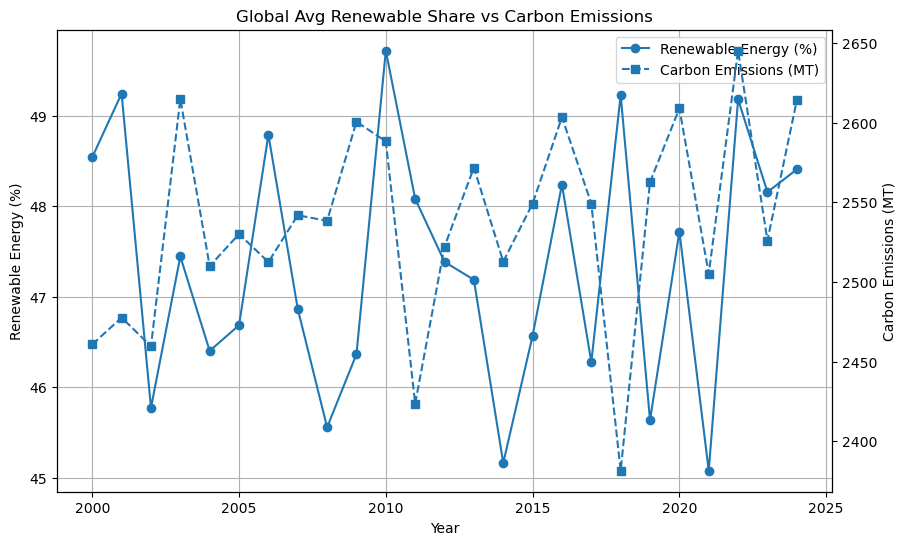

In [34]:
#Global Avg Renewable Share vs Carbon Emissions
# group data
renew_avg = df.groupby("Year")["Renewable Energy Share (%)"].mean()
carbon_avg = df.groupby("Year")["Carbon Emissions (Million Tons)"].mean()

# create plot
fig, ax1 = plt.subplots(figsize=(10,6))

# Renewable (left axis)
ax1.plot(
    renew_avg.index,
    renew_avg.values,
    marker='o',
    label="Renewable Energy (%)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Renewable Energy (%)")

# Carbon (right axis)
ax2 = ax1.twinx()

ax2.plot(
    carbon_avg.index,
    carbon_avg.values,
    marker='s',
    linestyle='--',
    label="Carbon Emissions (MT)"
)
ax2.set_ylabel("Carbon Emissions (MT)")

# Title
plt.title("Global Avg Renewable Share vs Carbon Emissions")

# Combine legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

# grid
ax1.grid(True)

plt.show()

In [7]:
#insight:
Two models were used:
Linear Regression → baseline model
Random Forest → non-linear ensemble model
Random Forest achieved better performance (higher R², lower RMSE) compared to Linear Regression.
This indicates that the relationship between energy variables and emissions is non-linear.
Feature interactions (e.g., fossil dependency + industrial usage) are better captured by Random Forest.
Linear Regression provides interpretability, while Random Forest provides accuracy.

SyntaxError: invalid character '→' (U+2192) (733595766.py, line 3)

In [47]:
forecast_results = {}
future_years = np.array([2025, 2026, 2027, 2028, 2029])

countries = df["Country"].unique()

for country in countries:
    subset = df[df["Country"] == country]

    years = subset["Year"].values
    renewable = subset["Renewable Energy Share (%)"].values

    # Linear regression
    z = np.polyfit(years, renewable, 1)
    p = np.poly1d(z)

    future_values = p(future_years)

    forecast_results[country] = {
        "years": years,
        "actual": renewable,
        "future": future_values,
        "slope": z[0]
    }

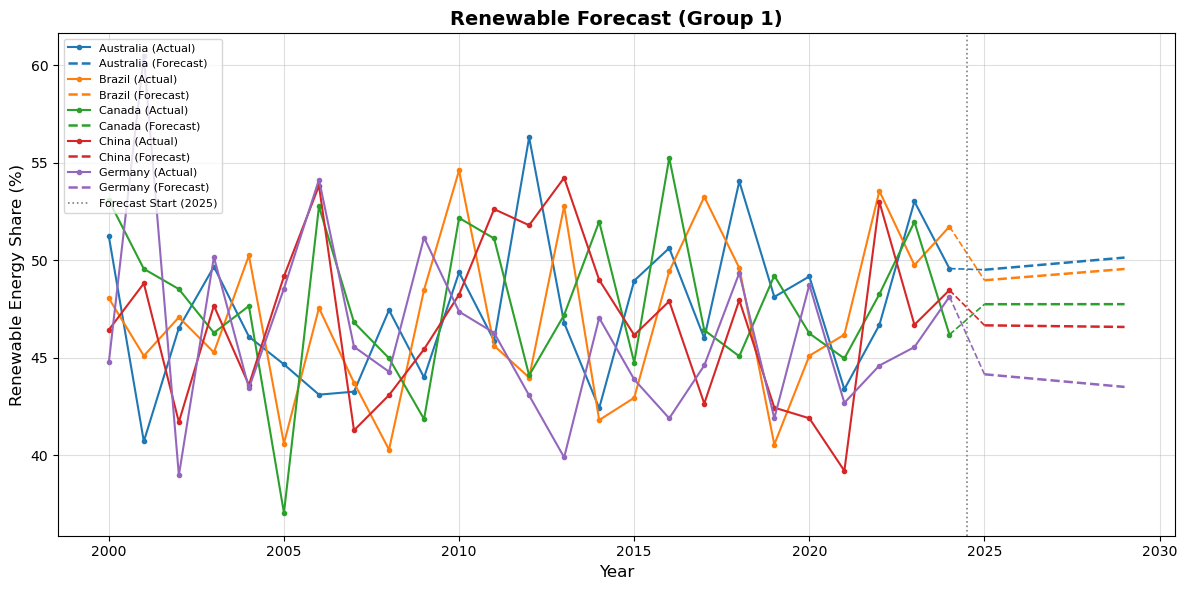

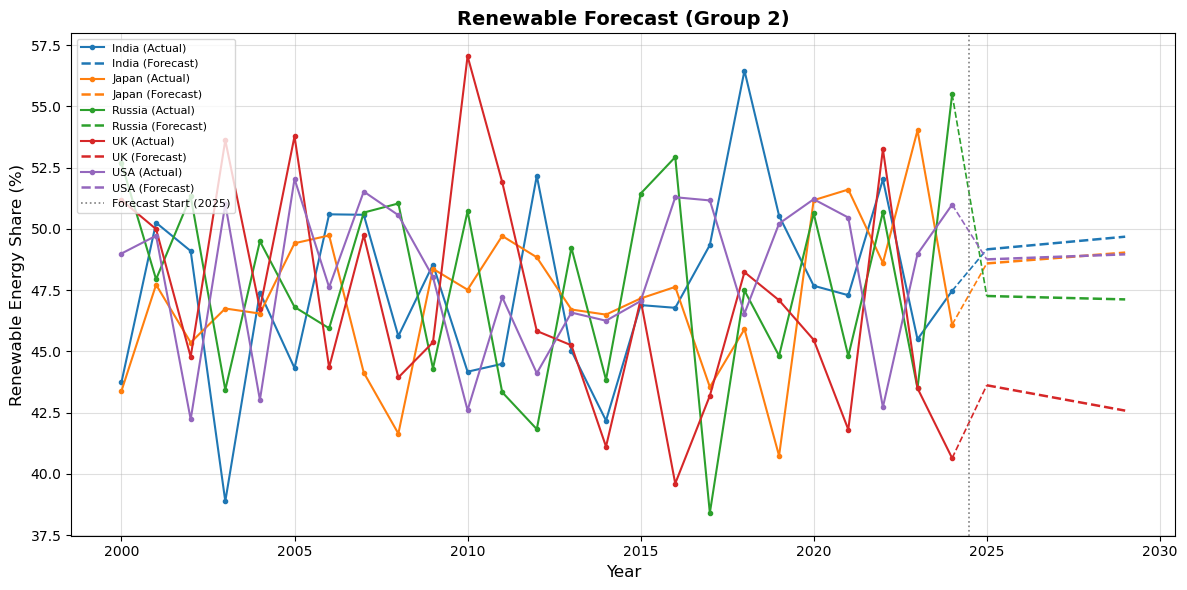


  Forecast Summary — Renewable Energy Share (2029)
  Country          2029 Forecast  Trend
-------------------------------------------------------
  Australia              50.14%  📈 Increasing
  Brazil                 49.55%  📈 Increasing
  Canada                 47.74%  📈 Increasing
  China                  46.58%  📉 Decreasing
  Germany                43.50%  📉 Decreasing
  India                  49.68%  📈 Increasing
  Japan                  49.03%  📈 Increasing
  Russia                 47.12%  📉 Decreasing
  UK                     42.58%  📉 Decreasing
  USA                    48.96%  📈 Increasing


In [53]:
## Objective 5: Renewable Energy Forecast

#Forecast renewable adoption (2025–2029)

# ── Aggregate: mean Renewable Energy Share per Country per Year ──────────────
df_agg = (
    df.groupby(["Country", "Year"])["Renewable Energy Share (%)"]
    .mean()
    .reset_index()
)
 
countries    = sorted(df_agg["Country"].unique().tolist())
future_years = list(range(2025, 2030))
 
# ── Build Forecast Results ───────────────────────────────────────────────────
forecast_results = {}
 
for country in countries:
    subset = df_agg[df_agg["Country"] == country].sort_values("Year")
 
    years  = subset["Year"].values
    actual = subset["Renewable Energy Share (%)"].values
 
    # Linear regression on historical data
    X = years.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, actual)
 
    slope     = model.coef_[0]
    future_X  = np.array(future_years).reshape(-1, 1)
    future    = model.predict(future_X)
    future    = np.clip(future, 0, 100)   # keep % in valid range
 
    forecast_results[country] = {
        "years":  years.tolist(),
        "actual": actual.tolist(),
        "future": future.tolist(),
        "slope":  slope,
    }
 
# ── Split into Two Groups ────────────────────────────────────────────────────
mid    = len(countries) // 2
group1 = countries[:mid]
group2 = countries[mid:]
 
# ── Plot Helper ──────────────────────────────────────────────────────────────
def plot_group(group, title):
    plt.figure(figsize=(12, 6))
 
    for country in group:
        data   = forecast_results[country]
        years  = data["years"]
        actual = data["actual"]
        future = data["future"]
 
        # Actual
        line, = plt.plot(
            years,
            actual,
            marker='o',
            markersize=3,
            linewidth=1.5,
            label=f"{country} (Actual)"
        )
        color = line.get_color()
 
        # Bridge: last actual → first forecast
        plt.plot(
            [years[-1], future_years[0]],
            [actual[-1], future[0]],
            linestyle='--',
            color=color,
            linewidth=1.2
        )
 
        # Forecast
        plt.plot(
            future_years,
            future,
            linestyle='--',
            color=color,
            linewidth=1.8,
            label=f"{country} (Forecast)"
        )
 
    plt.axvline(x=2024.5, linestyle=':', color='gray', linewidth=1.2,
                label='Forecast Start (2025)')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Renewable Energy Share (%)", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=8, loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
 
# ── Generate Plots ───────────────────────────────────────────────────────────
plot_group(group1, "Renewable Forecast (Group 1)")
plot_group(group2, "Renewable Forecast (Group 2)")
 
# ── Forecast Summary (2029) ──────────────────────────────────────────────────
print("\n" + "="*55)
print("  Forecast Summary — Renewable Energy Share (2029)")
print("="*55)
print(f"  {'Country':<15} {'2029 Forecast':>14}  {'Trend'}")
print("-"*55)
 
for country in countries:
    future_val = forecast_results[country]["future"][-1]
    slope      = forecast_results[country]["slope"]
    trend      = "📈 Increasing" if slope > 0 else "📉 Decreasing"
    print(f"  {country:<15} {future_val:>12.2f}%  {trend}")
 
print("="*55)

In [9]:
#insight:
Forecasting shows a gradual increase in renewable energy adoption for most countries.
Some countries exhibit stable trends, indicating slow transition.
The slope of the regression line helps determine whether a country is:
Increasing renewable adoption
Decreasing or stagnating
The model assumes linear growth, which may not fully capture real-world policy or technological changes.
Splitting countries into groups improves visualization clarity and interpretability.

SyntaxError: invalid syntax (1338723562.py, line 2)

In [10]:
##Conclusion
Global energy consumption is steadily increasing, driven by economic growth and industrialization.
Renewable energy adoption shows a moderate but limited impact on reducing carbon emissions.
Clustering reveals distinct energy profiles among countries, highlighting sustainability differences.
Machine learning results show that Random Forest outperforms Linear Regression, indicating non-linear relationships.
Forecasting suggests a slow but positive transition toward renewable energy, though changes are gradual.

SyntaxError: invalid syntax (1876595325.py, line 2)